## The use of generative LLMs as a comparison for subject-proxy scenario testing


In [7]:
#-------------------------------------------------------------------------------
# Setup and Imports
#-------------------------------------------------------------------------------
'''
This script contains the reproducible code to analyse and present the LLM vs Proxy treatment agreement with the Patient
in response to the hypothetical scenarios.'''

import torch
import pandas as pd
import numpy as np
import lightning as pl
import glob
import os

import transformers
import re
import matplotlib.pyplot as plt

import statsmodels.api as sm
from matplotlib import cm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import sem, t

from tqdm import tqdm
from pytorch_lightning import seed_everything
from statsmodels.stats.anova import AnovaRM


#-------------------------------------------------------------------------------
# Environment / Device Setup
#-------------------------------------------------------------------------------

def is_notebook():
    return 'JPY_PARENT_PID' in os.environ

USE_CUDA = torch.cuda.is_available()
device = torch.device('cuda' if USE_CUDA else 'cpu')
current_directory = os.getcwd()


#-------------------------------------------------------------------------------
# Parameters
#-------------------------------------------------------------------------------

no_dyads = 15
temperature_values = [0.0,0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
no_temps = len(temperature_values)

#-------------------------------------------------------------------------------------------
# ANALYSING OVERALL RESULTS - AUTOMATIC TRIALS
#-------------------------------------------------------------------------------------------
proxy_avg_results = [2,1,2,2,1,3,0,0,0,2,0,3,2,0,1]
proxy_avg_results_minus5 = [1,2,2,3,0,0,2,0,3,2,0,1]
proxy_avg = (np.mean(proxy_avg_results)/3)*100
proxy_avg_minus5 = (np.mean(proxy_avg_results_minus5)/3)*100
proxy_std_dev_minus5 = (np.std(proxy_avg_results_minus5) / 3) * 100
sem_minus5 = proxy_std_dev_minus5 / np.sqrt(len(proxy_avg_results_minus5))
confidence_interval_minus5 = 1.96 * sem_minus5
upper = confidence_interval_minus5 + proxy_avg_minus5
lower = proxy_avg_minus5 - confidence_interval_minus5
new_labels = ['LLM answering as the \nproxy (+ VQ)','LLM answering as the \nproxy (- VQ)','LLM answering as the \npatient (+ VQ)', 'LLM answering as the \npatient (- VQ)']

/blue/prismap-ai-core/vnolan/conda/envs/APARI2_Models/lib/python3.12/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
[rank: 0] Seed set to 42


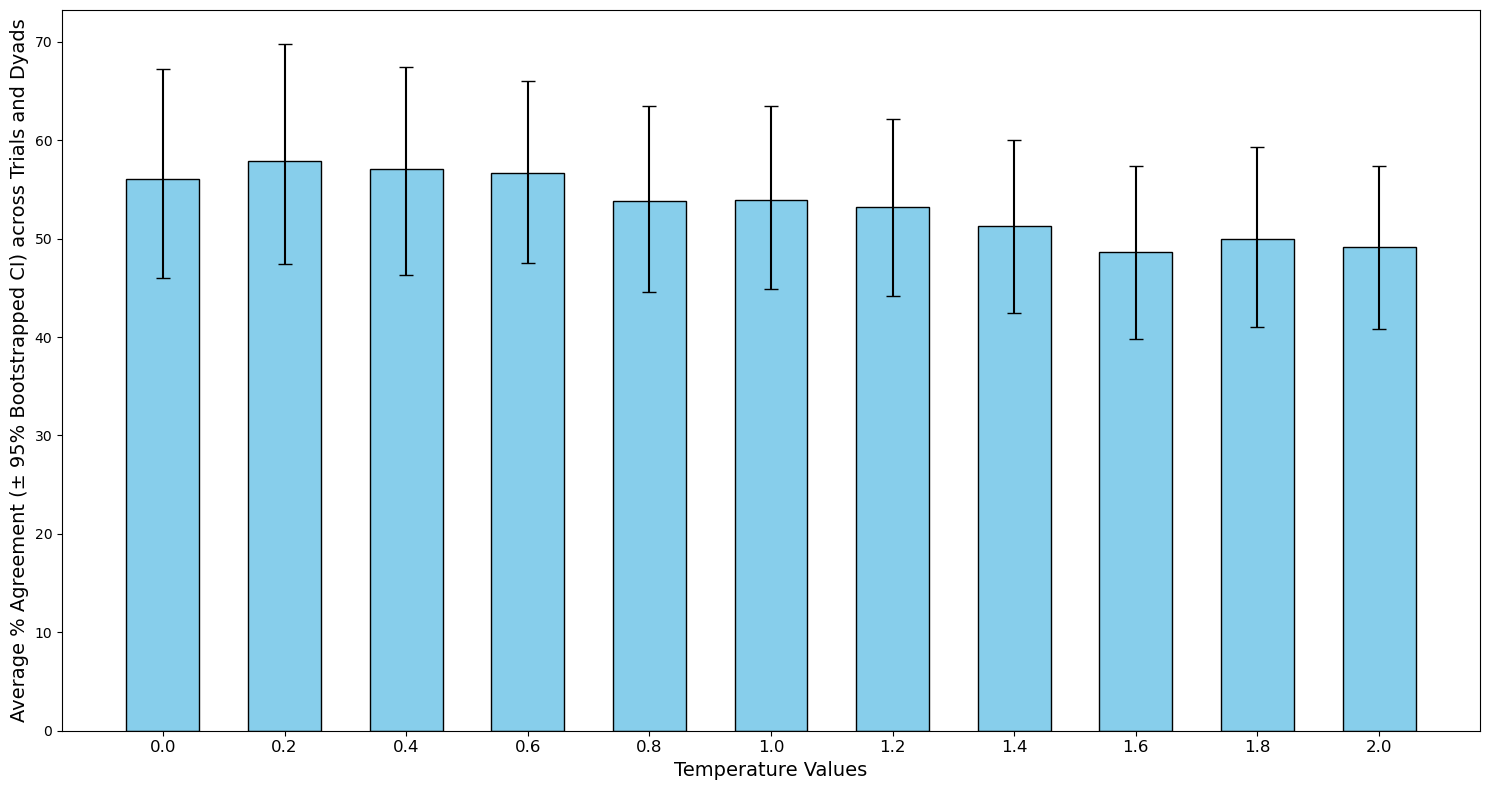

/scratch/local/14484278/ipykernel_1800290/2501556211.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues')


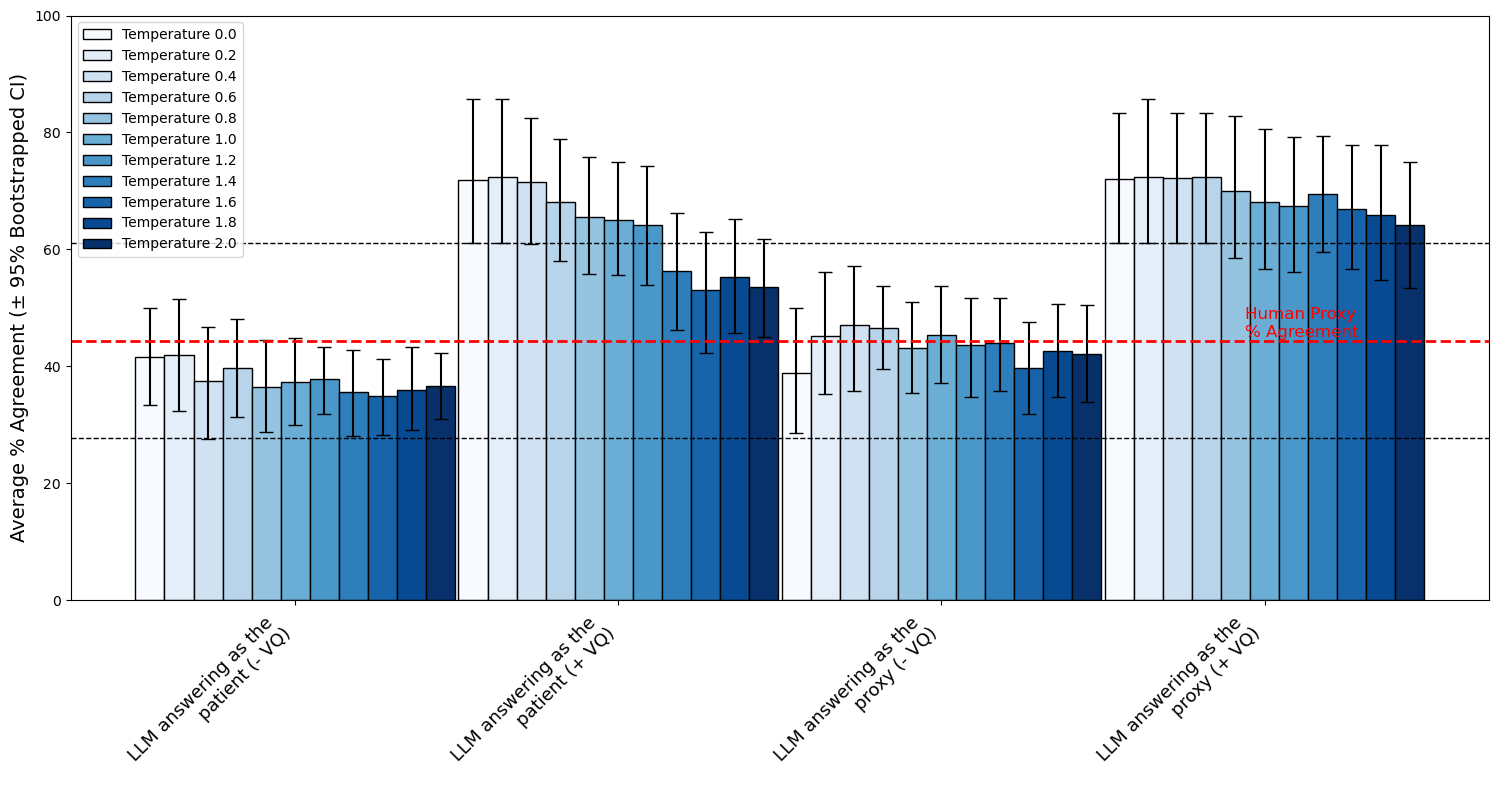

In [48]:
#---------------------------------------------------------------------------------------------------------------------------------------
############################################# TEMPERATURE TRIALS ###########################################
#---------------------------------------------------------------------------------------------------------------------------------------
trial_results = pd.read_csv('OllamaTrials3.csv')
trial_results = trial_results.melt(
    id_vars=['Dyad', 'Temperature', 'Trial'],
    value_vars=['AI Subject Without Values', 'AI Subject With Values','AI Proxy Without Values', 'AI Proxy With Values', 'Human Proxy'],
    var_name='Comparison Type',
    value_name='Answer')
trial_results['Answer'] = (trial_results['Answer'] / 3) * 100
trial_results = trial_results[~trial_results['Dyad'].isin([1, 5, 7])]

# Bootstrapped means and CIs
new_labels2 = [ 'LLM answering as the \npatient (- VQ)', 'LLM answering as the \npatient (+ VQ)','LLM answering as the \nproxy (- VQ)', 'LLM answering as the \nproxy (+ VQ)']
comparison_types = trial_results['Comparison Type'].unique()
temperatures = trial_results['Temperature'].unique()
temperatures = np.sort(trial_results['Temperature'].unique())
n_boot = 1000
boot_results = []
for temp in temperatures:
    for ctype in comparison_types:
        subset = trial_results[(trial_results['Temperature'] == temp) & (trial_results['Comparison Type'] == ctype)]
        dyads = subset['Dyad'].unique()
        boot_means = []
        for _ in range(n_boot):
            sampled_dyads = np.random.choice(dyads, size=len(dyads), replace=True)
            sample_df = subset[subset['Dyad'].isin(sampled_dyads)]
            boot_means.append(sample_df['Answer'].mean())
        mean_val = np.mean(boot_means)
        ci_lower = np.percentile(boot_means, 2.5)
        ci_upper = np.percentile(boot_means, 97.5)
        boot_results.append({
            'Comparison Type': ctype,
            'Temperature': temp,
            'Mean': mean_val,
            'CI Lower': ci_lower,
            'CI Upper': ci_upper})
summary_df_boot = pd.DataFrame(boot_results)

summary_df_boot['error_lower'] = summary_df_boot['Mean'] - summary_df_boot['CI Lower']
summary_df_boot['error_upper'] = summary_df_boot['CI Upper'] - summary_df_boot['Mean']
human_proxy_row = summary_df_boot[summary_df_boot['Comparison Type'] == 'Human Proxy'].iloc[0]
human_proxy_mean = human_proxy_row['Mean']
human_proxy_ci_lower = human_proxy_row['CI Lower']
human_proxy_ci_upper = human_proxy_row['CI Upper']
plot_df = summary_df_boot[summary_df_boot['Comparison Type'] != 'Human Proxy']

# Plot mean across temperatures
agg_df = plot_df.groupby('Temperature').agg(
    mean_answer=('Mean', 'mean'),
    ci_lower=('CI Lower', 'mean'),
    ci_upper=('CI Upper', 'mean')).reset_index()
agg_df['error_lower'] = agg_df['mean_answer'] - agg_df['ci_lower']
agg_df['error_upper'] = agg_df['ci_upper'] - agg_df['mean_answer']
x = np.arange(len(agg_df))
bar_width = 0.6
plt.figure(figsize=(15, 8))
plt.bar(
    x,
    agg_df['mean_answer'],
    bar_width,
    yerr=[agg_df['error_lower'], agg_df['error_upper']],
    capsize=5,
    color='skyblue',
    edgecolor='black')
plt.xticks(x, [str(t) for t in agg_df['Temperature']], rotation=0, ha='center', fontsize=12)
plt.xlabel('Temperature Values', fontsize=14)
plt.ylabel('Average % Agreement (± 95% Bootstrapped CI) across Trials and Dyads', fontsize=14)
plt.title('', fontsize=16)
plt.tight_layout()
plt.show()

# Plot bars by Temperature
cmap = cm.get_cmap('Blues')
norm = plt.Normalize(plot_df['Temperature'].min(), plot_df['Temperature'].max())
plt.figure(figsize=(15, 8))
bar_width = 0.09
positions = np.arange(len(plot_df['Comparison Type'].unique()))
for idx, temp in enumerate(temperatures):
    temp_df = plot_df[plot_df['Temperature'] == temp]
    color = cmap(norm(temp))
    plt.bar(
        positions + idx * bar_width,
        temp_df['Mean'],
        bar_width,
        yerr=[temp_df['error_lower'], temp_df['error_upper']],
        capsize=5,
        label=f'Temperature {temp}',
        color=color,
        edgecolor='black')
plt.text(
    positions[-1] + bar_width * (len(temperatures)) - 0.6,
    human_proxy_mean + 3,
    'Human Proxy\n% Agreement',
    color='red',
    fontsize=12,
    verticalalignment='center')
plt.xticks(
    positions + bar_width * (len(temperatures) - 1) / 2,
    new_labels2,
    rotation=45,
    ha='right',
    size=13)
plt.xlabel('')
plt.ylabel('Average % Agreement (± 95% Bootstrapped CI)', size=14)
plt.legend(title='')
plt.tight_layout()
plt.axhline(y=human_proxy_mean, color='red', linestyle='--', linewidth=2)
plt.axhline(y=human_proxy_ci_upper, color='black', linestyle='--', linewidth=1)
plt.axhline(y=human_proxy_ci_lower, color='black', linestyle='--', linewidth=1)
plt.ylim(0, 100)
plt.show()


In [11]:
#---------------------------------------------------------------------------------------------------------------------------------------
############################################# WITHOUT ANSWER 5 WITH TEMPERATURE OF 0.2 ###########################################
#---------------------------------------------------------------------------------------------------------------------------------------
trial_results = pd.read_csv('OllamaTrials3.csv')
trial_results = trial_results.melt(id_vars=['Dyad', 'Temperature', 'Trial'],
                    value_vars=['AI Subject Without Values', 'AI Subject With Values', 'AI Proxy Without Values', 'AI Proxy With Values', 'Human Proxy'],
                    var_name='Comparison Type', value_name='Answer')
trial_results['Answer'] = (trial_results['Answer'] / 3) * 100
trial_results = trial_results[~trial_results['Dyad'].isin([1, 5, 7])]
trial_results = trial_results[trial_results['Temperature'] == 0.2]

# CLUSTERED BOOTSTRAPPING OF MEAN AND CI
agg_results = trial_results.groupby(['Dyad', 'Comparison Type'], as_index=False)['Answer'].mean()
comparison_types = agg_results['Comparison Type'].unique()
n_boot = 1000
boot_means = {ctype: [] for ctype in comparison_types}
dyads = agg_results['Dyad'].unique()
for _ in range(n_boot):
    sampled_dyads = np.random.choice(dyads, size=len(dyads), replace=True)
    sample_df = agg_results[agg_results['Dyad'].isin(sampled_dyads)].copy()
    for ctype in comparison_types:
        mean_val = sample_df[sample_df['Comparison Type'] == ctype]['Answer'].mean()
        boot_means[ctype].append(mean_val)
summary_boot = []
for ctype in comparison_types:
    mean = np.mean(boot_means[ctype])
    ci_lower = np.percentile(boot_means[ctype], 2.5)
    ci_upper = np.percentile(boot_means[ctype], 97.5)
    summary_boot.append({
        'Comparison Type': ctype,
        'Mean': mean,
        'CI Lower': ci_lower,
        'CI Upper': ci_upper})
summary_df_boot = pd.DataFrame(summary_boot)
print(summary_df_boot)


             Comparison Type       Mean   CI Lower   CI Upper
0       AI Proxy With Values  72.871994  62.380952  85.714286
1    AI Proxy Without Values  45.181742  34.285714  55.714286
2     AI Subject With Values  72.600011  61.904762  85.714286
3  AI Subject Without Values  41.984226  32.380952  51.335714
4                Human Proxy  44.713324  28.571429  61.904762


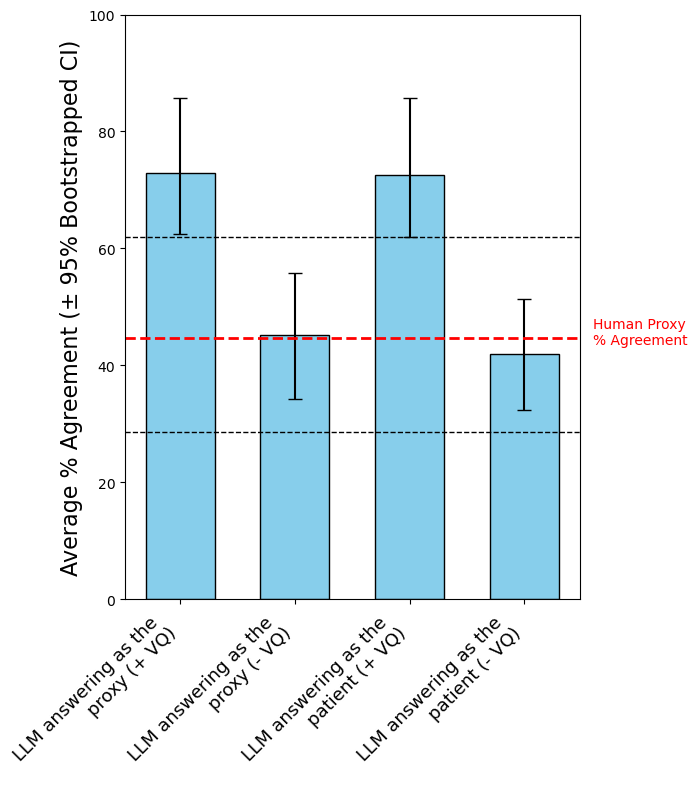

In [40]:
summary_df_boot['error_lower'] = summary_df_boot['Mean'] - summary_df_boot['CI Lower']
summary_df_boot['error_upper'] = summary_df_boot['CI Upper'] - summary_df_boot['Mean']
plot_df = summary_df_boot[summary_df_boot['Comparison Type'] != 'Human Proxy']
positions = np.arange(len(plot_df))
human_proxy_row = summary_df_boot[summary_df_boot['Comparison Type'] == 'Human Proxy'].iloc[0]
human_proxy_mean = human_proxy_row['Mean']
human_proxy_ci_lower = human_proxy_row['CI Lower']
human_proxy_ci_upper = human_proxy_row['CI Upper']

plt.figure(figsize=(7, 8))
plt.bar(
    positions,
    plot_df['Mean'],
    width=0.6,
    yerr=[plot_df['error_lower'], plot_df['error_upper']],
    capsize=5,
    edgecolor='black',
    color='skyblue')
plt.text(
    len(plot_df) - 0.4,
    human_proxy_mean + 1,
    'Human Proxy\n% Agreement',
    color='red',
    fontsize=10,
    verticalalignment='center')
plt.xticks(positions, new_labels, rotation=45, ha='right', size=13)
plt.ylabel('Average % Agreement (± 95% Bootstrapped CI)', size=16)
plt.xlabel('')
plt.tight_layout()
plt.axhline(y=human_proxy_mean, color='red', linestyle='--', linewidth=2)
plt.axhline(y=human_proxy_ci_upper, color='black', linestyle='--', linewidth=1)
plt.axhline(y=human_proxy_ci_lower, color='black', linestyle='--', linewidth=1)
plt.ylim(0, 100)
plt.show()